# 🚗 차량 손상 YOLO 학습 노트북

이 노트북은 AI Hub 데이터셋으로 YOLOv8-seg 모델을 학습하면서
**매 epoch마다 그래프를 실시간으로 업데이트**해서 보여줍니다.

## 학습 흐름
```
1. 데이터 확인  →  2. 샘플 시각화  →  3. 학습 시작  →  4. 실시간 그래프  →  5. 결과 확인
```

## 핵심 개념: 콜백(Callback)이란?
학습 중 특정 시점에 자동으로 호출되는 함수입니다.
- `on_val_end` → 매 epoch 검증이 끝날 때마다 호출
- 이 함수 안에서 `results.csv`를 읽고 그래프를 다시 그립니다.

## 1. 라이브러리 불러오기

In [ ]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
from PIL import Image
from ultralytics import YOLO

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
# 경로 설정
PROJECT_DIR = Path(".")
IMAGE_DIR   = Path("/Users/eunseoklee/Downloads/New_Sample/원천데이터/TS_damage/damage")
LABEL_DIR   = Path("/Users/eunseoklee/Downloads/New_Sample/라벨링데이터/TL_damage/damage")
YAML_PATH   = PROJECT_DIR / "data" / "car_damage.yaml"
MODEL_DIR   = PROJECT_DIR / "models"

CLASS_NAMES = {0: "Scratched", 1: "Breakage", 2: "Separated", 3: "Crushed"}
CLASS_KO    = {0: "긁힘",      1: "파손",     2: "분리",      3: "찌그러짐"}
COLORS      = ["#3498db", "#e74c3c", "#f39c12", "#9b59b6"]

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 2. 데이터셋 통계 확인

학습 데이터가 어떻게 구성되어 있는지 먼저 파악합니다.

/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/3346572779.py:21: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/3346572779.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/3346572779.py:21: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/3346572779.py:21: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/3346572779.py:21: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipyker

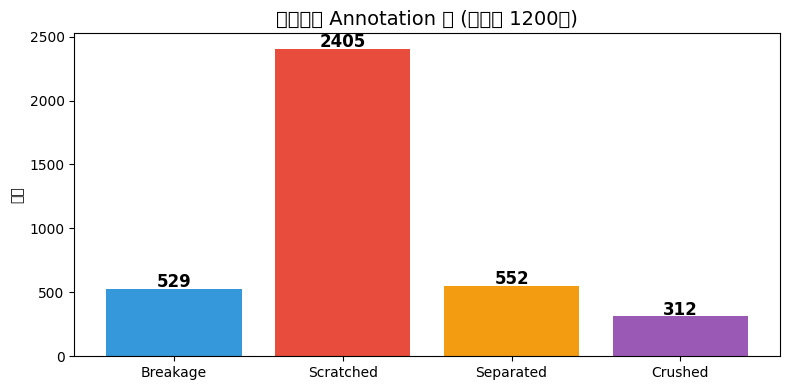

총 이미지: 1200장 | 총 Annotation: 3798개
  Scratched   : 2405개 (63.3%)
  Separated   :  552개 (14.5%)
  Breakage    :  529개 (13.9%)
  Crushed     :  312개 (8.2%)


In [2]:
damage_counter = Counter()
total_images   = 0

for f in LABEL_DIR.glob("*.json"):
    data = json.loads(f.read_text())
    for ann in data.get("annotations", []):
        damage_counter[ann.get("damage", "None")] += 1
    total_images += 1

labels = list(damage_counter.keys())
counts = list(damage_counter.values())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts, color=COLORS[:len(labels)])
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha="center", fontsize=12, fontweight="bold")

ax.set_title(f"클래스별 Annotation 수 (이미지 {total_images}장)", fontsize=14)
ax.set_ylabel("개수")
plt.tight_layout()
plt.show()

print(f"총 이미지: {total_images}장 | 총 Annotation: {sum(counts)}개")
for cls, cnt in damage_counter.most_common():
    print(f"  {cls:12s}: {cnt:4d}개 ({cnt/sum(counts)*100:.1f}%)")

## 3. 샘플 이미지 + 라벨 시각화

실제 학습 데이터가 어떻게 생겼는지 확인합니다.
색상 오버레이가 segmentation 마스크 (손상 영역)입니다.

/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/634673632.py:37: UserWarning: Glyph 44545 (\N{HANGUL SYLLABLE GEULG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/634673632.py:37: UserWarning: Glyph 55192 (\N{HANGUL SYLLABLE HIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/634673632.py:37: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/634673632.py:37: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_22502/634673632.py:37: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bx/9gqfpk1n1yb6y2td6qtmbn800000gn/T/ipykernel_2

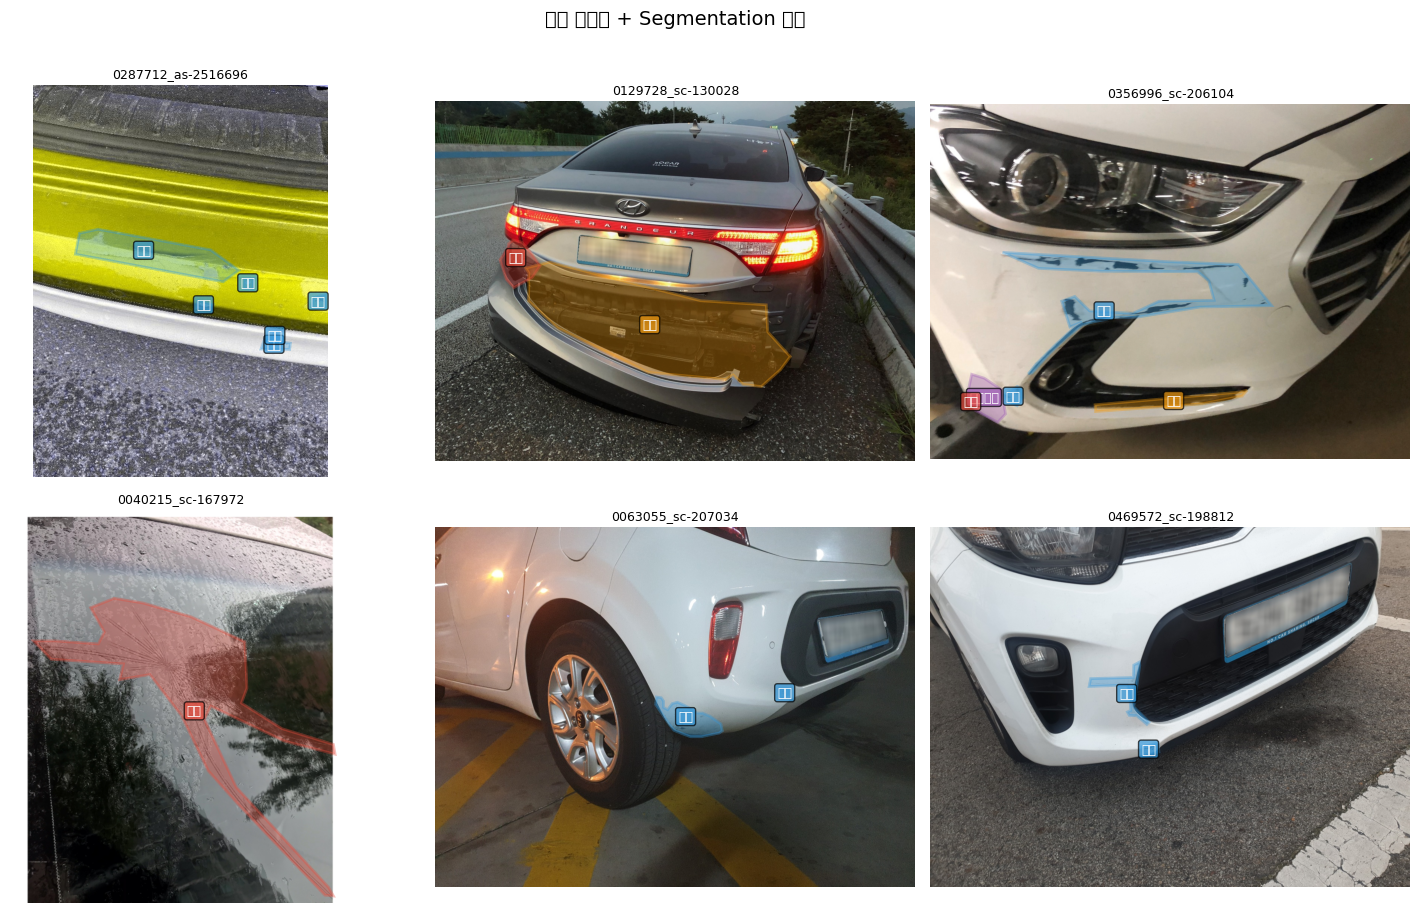

In [3]:
random.seed(7)
sample_labels = random.sample(sorted(LABEL_DIR.glob("*.json")), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, lbl_path in zip(axes.flat, sample_labels):
    data     = json.loads(lbl_path.read_text())
    img_file = IMAGE_DIR / lbl_path.name.replace(".json", ".jpg")

    if not img_file.exists():
        ax.axis("off")
        continue

    ax.imshow(np.array(Image.open(img_file)))

    for ann in data.get("annotations", []):
        cls  = ann.get("damage", "")
        seg  = ann.get("segmentation", [])
        cidx = list(CLASS_NAMES.values()).index(cls) if cls in CLASS_NAMES.values() else 0
        col  = COLORS[cidx]

        if seg and seg[0] and seg[0][0]:
            pts  = np.array(seg[0][0])
            poly = mpatches.Polygon(pts, closed=True, fill=True,
                                    facecolor=col, alpha=0.35,
                                    edgecolor=col, linewidth=2)
            ax.add_patch(poly)
            ax.text(pts[:,0].mean(), pts[:,1].mean(),
                    CLASS_KO.get(cidx, cls), color="white",
                    fontsize=9, fontweight="bold", ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor=col, alpha=0.7))

    ax.set_title(lbl_path.stem[:25], fontsize=9)
    ax.axis("off")

plt.suptitle("샘플 이미지 + Segmentation 라벨", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. YOLO 학습 — 실시간 그래프

### 원리
```
model.train() 실행
  └─ 1 epoch 학습
  └─ 검증 (val)
  └─ results.csv 업데이트
  └─ on_val_end 콜백 호출  ← 여기서 그래프 갱신
  └─ 다음 epoch...
```

> ⚠️ 이미 백그라운드에서 학습이 돌고 있다면, 터미널에서 먼저 종료하세요:
> ```bash
> kill $(lsof -ti:$(pgrep -f train_yolo))
> ```

In [4]:
def plot_live(trainer):
    """
    매 epoch 검증 후 자동 호출.
    results.csv → Loss + mAP 그래프 실시간 갱신.
    """
    results_csv = Path(trainer.save_dir) / "results.csv"
    if not results_csv.exists():
        return

    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    if df.empty:
        return

    latest    = df.iloc[-1]
    cur_epoch = int(latest["epoch"])

    clear_output(wait=True)  # 이전 그래프 지우고 새로 그리기

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Train Loss
    axes[0].plot(df["epoch"], df["train/box_loss"], label="box", color="#3498db")
    axes[0].plot(df["epoch"], df["train/seg_loss"], label="seg", color="#e74c3c")
    axes[0].plot(df["epoch"], df["train/cls_loss"], label="cls", color="#2ecc71")
    axes[0].set_title("Train Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Val Loss
    axes[1].plot(df["epoch"], df["val/box_loss"], label="box", color="#3498db", linestyle="--")
    axes[1].plot(df["epoch"], df["val/seg_loss"], label="seg", color="#e74c3c", linestyle="--")
    axes[1].plot(df["epoch"], df["val/cls_loss"], label="cls", color="#2ecc71", linestyle="--")
    axes[1].set_title("Val Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

    # mAP50
    axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],
                 label="mAP50 Box",  color="#9b59b6", linewidth=2)
    axes[2].plot(df["epoch"], df["metrics/mAP50(M)"],
                 label="mAP50 Mask", color="#f39c12", linewidth=2)
    axes[2].set_ylim(0, 1); axes[2].set_title("mAP50")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle(
        f"Epoch {cur_epoch}/100  │  "
        f"mAP50(Box): {latest['metrics/mAP50(B)']:.4f}  │  "
        f"mAP50(Mask): {latest['metrics/mAP50(M)']:.4f}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

print("✅ 콜백 함수 정의 완료")

✅ 콜백 함수 정의 완료


In [ ]:
# 학습 실행 — 이전 체크포인트 있으면 자동으로 이어받기
LAST_PT = MODEL_DIR / "car_damage_seg" / "weights" / "last.pt"

if LAST_PT.exists():
    # ── 이어받기 모드 ──────────────────────────────────────
    print("✅ last.pt 발견 → 중단된 epoch부터 이어받기")
    model = YOLO(str(LAST_PT))
    model.add_callback("on_val_end", plot_live)
    results = model.train(resume=True)
else:
    # ── 처음부터 학습 ──────────────────────────────────────
    print("🆕 처음부터 학습 시작")
    model = YOLO("yolov8n-seg.pt")
    model.add_callback("on_val_end", plot_live)
    results = model.train(
        data=str(YAML_PATH),
        epochs=30,       # 공부용: 30 epoch (약 1시간)
        imgsz=640,
        batch=8,
        device="mps",    # M1/M2 → mps | GPU없으면 → "cpu"
        workers=4,
        project=str(MODEL_DIR),
        name="car_damage_seg",
        exist_ok=True,
        patience=20,
        save_period=5,
        verbose=False,
    )

print("\n🎉 학습 완료!")
print(f"Best mAP50(Box):  {results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
print(f"Best mAP50(Mask): {results.results_dict.get('metrics/mAP50(M)', 0):.4f}")

✅ last.pt 발견 → 중단된 epoch부터 이어받기
Ultralytics 8.4.87 🚀 Python-3.10.6 torch-2.12.1 MPS (Apple M1 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/eunseoklee/Desktop/car-damage-analyzer/data/car_damage.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/car_damage_seg/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_damage_seg, nbs

## 5. 학습 완료 후 전체 결과 분석

In [ ]:
results_csv = MODEL_DIR / "car_damage_seg" / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].plot(df["epoch"], df["train/box_loss"], color="#3498db")
axes[0,0].set_title("Train Box Loss"); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(df["epoch"], df["train/seg_loss"], color="#e74c3c")
axes[0,1].set_title("Train Seg Loss"); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(df["epoch"], df["train/cls_loss"], color="#2ecc71")
axes[0,2].set_title("Train Cls Loss"); axes[0,2].grid(alpha=0.3)

axes[1,0].plot(df["epoch"], df["val/box_loss"], color="#3498db", linestyle="--")
axes[1,0].set_title("Val Box Loss"); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(df["epoch"], df["val/seg_loss"], color="#e74c3c", linestyle="--")
axes[1,1].set_title("Val Seg Loss"); axes[1,1].grid(alpha=0.3)

best_epoch = int(df.loc[df["metrics/mAP50(B)"].idxmax(), "epoch"])
axes[1,2].plot(df["epoch"], df["metrics/mAP50(B)"],
               label="mAP50 Box",  color="#9b59b6", linewidth=2)
axes[1,2].plot(df["epoch"], df["metrics/mAP50(M)"],
               label="mAP50 Mask", color="#f39c12", linewidth=2)
axes[1,2].axvline(best_epoch, color="red", linestyle=":", label=f"Best ({best_epoch}epoch)")
axes[1,2].set_title("mAP50"); axes[1,2].set_ylim(0, 1)
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.suptitle("학습 완료 — 전체 결과", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Best Epoch: {best_epoch}")
print(f"최고 mAP50(Box):  {df['metrics/mAP50(B)'].max():.4f}")
print(f"최고 mAP50(Mask): {df['metrics/mAP50(M)'].max():.4f}")

## 6. 실제 이미지로 추론 테스트

In [ ]:
best_pt   = MODEL_DIR / "best.pt"
model_inf = YOLO(str(best_pt))

val_images = list((PROJECT_DIR / "data" / "yolo_dataset" / "images" / "val").glob("*.jpg"))
test_img   = random.choice(val_images)

results = model_inf.predict(str(test_img), conf=0.25, iou=0.45, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(Image.open(test_img))
axes[0].set_title("원본 이미지", fontsize=12)
axes[0].axis("off")

annotated = results[0].plot()[:, :, ::-1]  # BGR → RGB
axes[1].imshow(annotated)

n_det = len(results[0].boxes) if results[0].boxes else 0
axes[1].set_title(f"YOLO 감지 결과 ({n_det}개)", fontsize=12)
axes[1].axis("off")

plt.tight_layout()
plt.show()

if results[0].boxes and len(results[0].boxes) > 0:
    print("감지된 손상:")
    for box in results[0].boxes:
        cls_id = int(box.cls.item())
        conf   = float(box.conf.item())
        print(f"  {CLASS_KO[cls_id]} ({CLASS_NAMES[cls_id]}) — 신뢰도: {conf:.1%}")
else:
    print("감지된 손상 없음")